<a href="https://colab.research.google.com/github/geraldiakmal2380/PCVK_Ganjil_2026/blob/main/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Apa yang dilakukan di praktikum ini?

# **Disclaimer of AI Use :**
Ringkasan ini dibuat dengan bantuan AI. AI membantu saya untuk belajar dan mengerjakan tugas ini.

# **1.Inverse Citra:**
Nilai citra dibalik dengan mengurangkan nilai maksimum piksel (255) dengan nilai piksel asli, sehingga menghasilkan citra negatif.

#**2.Transformasi Contrast:**
Kontras dimodifikasi dengan menghitung Contrast Correction Factor (F), kemudian diaplikasikan pada setiap piksel warna (R, G, B) yang nilainya dibatasi menggunakan fungsi Truncate agar tetap di rentang 0-255

#**3.Transformasi Logarithmic:**
Memetakan rentang input keabuan yang sempit menjadi lebih lebar dengan rumus s = c * log(1 + r)

#**4.Grayscale:**
Mengubah citra warna menjadi keabuan (8 bit) menggunakan tiga metode:

**-Averaging:** Merata-rata channel R, G, B.   
**-bightness:** Merata-rata nilai tertinggi dan terendah dari channel R, G, B.   
**-Luminance:** Memberikan bobot spesifik pada tiap channel (0.21R + 0.72G + 0.07B)

#**5.Gamma Correction:**
Menyesuaikan kecerahan kurva gambar dimana input dipangkatkan dengan invers dari nilai gamma

#**6.Simulasi Bit Depth:**
Mengurangi Bit Depth. Misalnya dari 8 bit ke 7 bit dan lain2.

#**7.Average Denoising dan PSNR:**
Menghilangkan noise dengan merata ratakan pixel pada kumpulan gambar yang sama. Diukur kualitasnya dengan Peak Signal to Noise Ratio (PSNR)

#**8.Image Masking:**
Menggunakan Logika AND, OR, NOT, XOR pada dua citra untuk memanipulasi area tertentu gambar.

# 1. Mount Google Drive ke sini


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Biasalah import module

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np #Ini dipake untuk truncate pada Nomor 4.
from google.colab.patches import cv2_imshow #Fix bug di google colab saat menampilkan gambar

# 3. Invert Warna Gambar

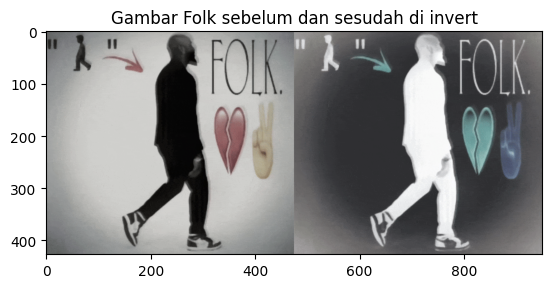

In [5]:
img_path = "/content/drive/MyDrive/Praktikum PCVK 2026/Folk.png"
original =  cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB) #baca gambarnya sekaligus langsung di konvert

# Cara invers warna adalah 255 dikurangi dengan value setiap warna dari pixel
orignal_but_inversed = 255 - original

final_frame = cv2.hconcat((original, orignal_but_inversed)) #jangan lupa kurungnya harus double. Entah kenapa ngebug kalau gak double
plt.title("Gambar Folk sebelum dan sesudah di invert")
plt.imshow(final_frame)

# 4. Ganti Contrast dan tingkat cahaya (GIMP is free bro)

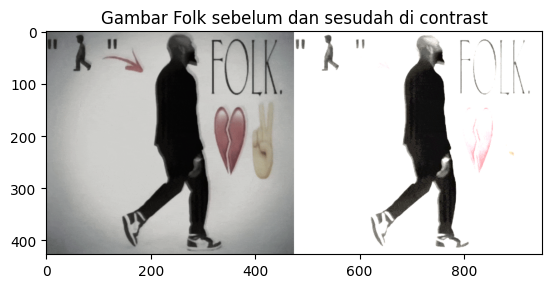

In [12]:
contrast_level = 120 #Ini value buat masukin ke gambar.

image_contrast = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)#Buat variabel baru lagi untuk masukan gambar

# Menghitung factor F sesuai rumus dari modul (real)
F = (259 * (contrast_level + 255)) / (255 * (259 - contrast_level))

#Setelah dihitung, aplikasikan ke rumus ke gambar dan truncate value nya dari 0 - 255 agar tidak ngebug.
image_contrast_converted = np.clip((F * image_contrast.astype(float) - 128) + 128, 0, 255).astype(np.uint8) #jujur gak paham ini buat apa

final_frame = cv2.hconcat((image_contrast, image_contrast_converted))
plt.title("Gambar Folk sebelum dan sesudah di contrast")
plt.imshow(final_frame)

# 5. Mengubah gambar menjadi Grayscale

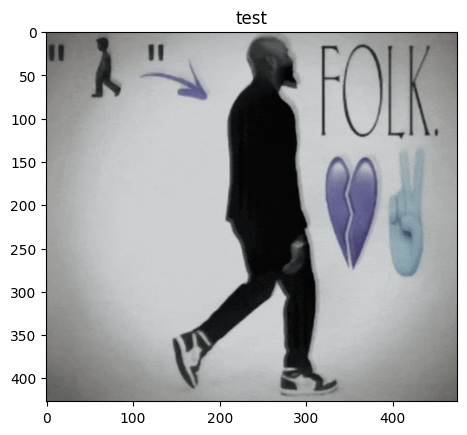

In [16]:
#buat variabel baru untuk memisahkan gambar dari sektor lain
image_grayscale = cv2.imread(img_path)

#pisah channel B, G, R. Bukan RGB
B, G, R = cv2.split(image_grayscale)

#step 1 Averaging
img_average = (R.astype(float) + G.astype(float) + B.astype(float)) /3
img_average = img_average.astype(np.uint8)

#step 2

#step 4 print gambarnya
plt.title("test")
plt.imshow(image_grayscale)

